# Rechecking every number in the draft — demo

This artifact is a **pure re-analysis**: `$0.00` of LLM spend, **0** model weights loaded,
**0** forward passes, **0** generations, **0** Hub fetches. The original `eval.py` reads six
archived experiment trees and re-derives every number the paper draft quotes, emitting an
**assertion table** where each row carries `(draft_quoted_value, recomputed_value, tolerance,
verdict, provenance)`.

Full run: **110 claim_ids -> 105 MATCH / 5 MISMATCH / 0 UNAVAILABLE** (~21 s on 4 CPUs).

This notebook replays the *comparison core* of that evaluation on a curated 100-row subset of the
shipped assertion table (all 5 MISMATCH rows plus 95 MATCH rows stratified across the five
tolerance classes). The verdict logic (`TOL`, `_row`) and the interval helpers (`wilson95`,
`boot_rate_ci`) are copied verbatim from `ws_assert.py` / `lib_arch.py`; we re-run them on the
archived `(quoted, recomputed)` pairs and check that every verdict reproduces.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python3.12 -m pip install --upgrade pip


In [2]:
# Imports as in the original scripts (eval.py / ws_assert.py / lib_arch.py), plus matplotlib
from __future__ import annotations

import json
import math
import os
from typing import Any

import numpy as np
import matplotlib.pyplot as plt

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-c9546e-rating-model-safety-in-eighty-forward-pa/main/round-4/evaluation-1/demo/mini_demo_data.json"

def _ok(d):
    # this demo needs the assertion-table payload; guard against a stale file at the URL
    return isinstance(d, dict) and "examples" in d and "metadata" in d

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            d = json.loads(response.read().decode())
        if _ok(d): return d
    except Exception: pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            d = json.load(f)
        if _ok(d): return d
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
print(data["metadata"]["evaluation_name"])
print("subset rows:", len(data["examples"]), "| full-run rows:", data["metadata"]["n_assertions_full"])
print("full-run verdicts:", data["metadata"]["assertion_verdict_counts_full"])
print("declared tolerances:", json.dumps(data["metadata"]["assertion_tolerances"], indent=2))

Recheck every number in the draft
subset rows: 100 | full-run rows: 110
full-run verdicts: {'MATCH': 105, 'MISMATCH': 5, 'UNAVAILABLE': 0}
declared tolerances: {
  "float_rederivation": 0.0001,
  "rate_from_reconstructed_counts": 0.005,
  "repo_ids_and_evidence_spans": "exact string match",
  "verbatim_copy": 1e-06
}


## Config

All tunable parameters. `N_ASSERTIONS` is how many rows of the archived assertion table we replay,
`BOOT_B` is the bootstrap replicate count (original: 10,000), `SEED` is the original run's seed.

In [5]:
# --- tunable parameters (original values in comments) ---
N_ASSERTIONS = 100      # rows of the assertion table to replay (full run: 110)
BOOT_B       = 10000    # bootstrap replicates for the rate CI (original: 10000)
SEED         = data["metadata"]["seed"]   # 20260814, the original run's seed

rows_in = data["examples"][:N_ASSERTIONS]
print(f"replaying {len(rows_in)} assertion rows | BOOT_B={BOOT_B} | SEED={SEED}")

replaying 100 assertion rows | BOOT_B=10000 | SEED=20260814


## 1. The verdict logic, verbatim

`TOL` and `_row` are copied unchanged from `ws_assert.py`. Every claim is compared under a
tolerance declared **up front** by its class: `1e-6` for values copied verbatim out of an archive,
`1e-4` for float re-derivations, `0.005` for rates rebuilt from reconstructed counts, exact string
equality for repo_ids and evidence spans, and `5.001e-4` for a draft value quoted at 3 dp against
its full-precision source.

In [6]:
# Tolerances declared up front.
TOL = {
    "verbatim": 1e-6,       # values copied verbatim from an archive
    "float_rederive": 1e-4,  # float re-derivations
    "rate_reconstructed": 0.005,  # rates re-derived from reconstructed counts
    "exact_string": 0.0,     # repo_ids and evidence spans
    "quoted_rounding": 5.001e-4,  # a draft value quoted at 3 dp against its full-precision source
}


def _row(claim_id: str, quoted: Any, recomputed: Any, tol_key: str, provenance: str) -> dict[str, Any]:
    tol = TOL[tol_key]
    if recomputed is None:
        return {"claim_id": claim_id, "draft_quoted_value": quoted, "recomputed_value": None,
                "abs_diff": None, "tolerance": tol, "tolerance_class": tol_key,
                "verdict": "UNAVAILABLE", "provenance": provenance}
    if not isinstance(quoted, (int, float)) or not isinstance(recomputed, (int, float)) \
            or isinstance(quoted, bool) or isinstance(recomputed, bool):
        ok = quoted == recomputed
        return {"claim_id": claim_id, "draft_quoted_value": quoted, "recomputed_value": recomputed,
                "abs_diff": 0.0 if ok else None, "tolerance": tol, "tolerance_class": tol_key,
                "verdict": "MATCH" if ok else "MISMATCH", "provenance": provenance}
    d = abs(float(quoted) - float(recomputed))
    return {"claim_id": claim_id, "draft_quoted_value": quoted, "recomputed_value": recomputed,
            "abs_diff": d, "tolerance": tol, "tolerance_class": tol_key,
            "verdict": "MATCH" if d <= tol else "MISMATCH", "provenance": provenance}

## 2. Replay the assertion table

The archived rows store the quoted / recomputed pair as strings (that is how they are shipped in
`eval_out.json`). We coerce back to float where the pair is numeric — a value that cannot be parsed
as a float stays a string and falls through `_row`'s exact-equality branch, which is exactly what
the original does for `repo_id` and evidence-span claims. A `None` recomputed value yields
`UNAVAILABLE`.

Each replayed verdict is then checked against the verdict the original run emitted.

In [7]:
def _maybe_float(x):
    """Archived rows ship values as strings; restore numerics, leave genuine strings alone."""
    if x is None:
        return None
    if isinstance(x, (int, float)):
        return x
    try:
        return float(x)
    except (TypeError, ValueError):
        return x


replayed = []
for ex in rows_in:
    q = _maybe_float(ex["predict_draft_quoted_value"])
    r = _maybe_float(ex["predict_recomputed_value"])
    replayed.append(_row(ex["input"], q, r, ex["metadata_tolerance_class"], ex["metadata_provenance"]))

counts = {"MATCH": 0, "MISMATCH": 0, "UNAVAILABLE": 0}
for row in replayed:
    counts[row["verdict"]] += 1

agree = sum(1 for row, ex in zip(replayed, rows_in) if row["verdict"] == ex["output"])
print("replayed verdict counts:", counts)
print(f"verdicts reproducing the archived run: {agree}/{len(replayed)}")
print("match rate on this subset:", round(counts["MATCH"] / len(replayed), 6))

replayed verdict counts: {'MATCH': 95, 'MISMATCH': 5, 'UNAVAILABLE': 0}
verdicts reproducing the archived run: 100/100
match rate on this subset: 0.95


## 3. Wilson + bootstrap interval on the match rate

`wilson95` and `boot_rate_ci` are copied verbatim from `lib_arch.py`. Wilson is the **primary**
interval throughout the evaluation (it is the one that behaves for small `n` and for rates near 0
or 1); the item-level nonparametric bootstrap is reported beside it as a cross-check.

In [8]:
def wilson95(k: int, n: int) -> tuple[float, float]:
    """Wilson score interval (primary for small n and rates near 0)."""
    if n <= 0:
        return (float("nan"), float("nan"))
    z = 1.959963984540054
    p = k / n
    d = 1.0 + z * z / n
    c = p + z * z / (2 * n)
    hw = z * math.sqrt(p * (1 - p) / n + z * z / (4 * n * n))
    return ((c - hw) / d, (c + hw) / d)


def boot_rate_ci(k: int, n: int, rng: np.random.Generator, b: int = BOOT_B) -> tuple[float, float]:
    """Item-level nonparametric bootstrap of a binomial rate."""
    if n <= 0:
        return (float("nan"), float("nan"))
    items = np.zeros(n)
    items[:k] = 1.0
    draws = rng.integers(0, n, size=(b, n))
    reps = items[draws].mean(axis=1)
    return (float(np.percentile(reps, 2.5)), float(np.percentile(reps, 97.5)))


rng = np.random.default_rng(SEED)
k, n = counts["MATCH"], len(replayed)
wlo, whi = wilson95(k, n)
blo, bhi = boot_rate_ci(k, n, rng)
print(f"match rate {k}/{n} = {k/n:.4f}")
print(f"  wilson95    [{wlo:.4f}, {whi:.4f}]")
print(f"  bootstrap95 [{blo:.4f}, {bhi:.4f}]   (B={BOOT_B})")
print(f"  full-run match rate (110 rows): {data['metadata']['assertion_match_rate_full']:.4f}")

match rate 95/100 = 0.9500
  wilson95    [0.8882, 0.9785]
  bootstrap95 [0.9000, 0.9900]   (B=10000)
  full-run match rate (110 rows): 0.9545


## 4. The disagreements — the actual product

The five MISMATCH rows are the point of the whole evaluation: each one is a number in the draft
that does not survive recomputation, classified rather than merely flagged (stale denominators, a
stale count, an undercount of unreproduced quoted values, and one case where the *value* was right
but the **subset label** was not).

In [9]:
mismatches = [row for row in replayed if row["verdict"] != "MATCH"]
print(f"{len(mismatches)} disagreement(s) in this subset\n")
for row in mismatches:
    print(f"claim_id   : {row['claim_id']}")
    print(f"  quoted     : {row['draft_quoted_value']}")
    print(f"  recomputed : {row['recomputed_value']}")
    print(f"  abs_diff   : {row['abs_diff']}   tol={row['tolerance']} ({row['tolerance_class']})")
    print(f"  provenance : {row['provenance']}")
    print(f"  verdict    : {row['verdict']}\n")

5 disagreement(s) in this subset

claim_id   : W2.n_real_intensity_axes_quoted_as_6
  quoted     : 6.0
  recomputed : 7.0
  abs_diff   : 1.0   tol=1e-06 (verbatim)
  provenance : A2 crossing dataset, rows with a real intensity axis
  verdict    : MISMATCH

claim_id   : W4.B09_abs_rho_member_0.766_against_28_member_contract_subset
  quoted     : 0.766
  recomputed : 0.67
  abs_diff   : 0.09599999999999997   tol=0.0001 (float_rederive)
  provenance : A5/numbers.json correlations.member.B09.harmful_refusal_rate (n=28) - EXPECTED MISMATCH: this is the subset the draft states
  verdict    : MISMATCH

claim_id   : W4.n_subset_corrected_values_quoted_as_4
  quoted     : 4.0
  recomputed : 5.0
  abs_diff   : 1.0   tol=1e-06 (verbatim)
  provenance : A5/numbers.json quoted_value_forensics.closest_match_per_quoted_value - the plan says FOUR draft-quoted 'correlations' are paired differences on a different subset; the forensics block carries this many
  verdict    : MISMATCH

claim_id   : W5.skip

## 5. Cross-check gates and scope

Two gates guard the re-analysis itself, both carried in the archived metadata: the arm-2
`verify.py` re-run (17/17 PASS) and the arm-1 weight-statistics gate (`max|dW05|` ~ 1e-5, Spearman
1.0000, ordering preserved). The scope constraints record what the evaluation deliberately did
*not* do.

In [10]:
gates = data["metadata"]["cross_check_gates"]
for name, g in gates.items():
    print(f"[{name}]")
    for kk, vv in g.items():
        print(f"   {kk}: {vv}")
    print()
print("scope constraints:")
for kk, vv in data["metadata"]["scope_constraints"].items():
    print(f"   {kk}: {vv}")

[verify_py]
   exit_code: 0
   gate_17_of_17: True
   n_pass: 17
   n_total: 17
   ran: True
   stderr_tail: 
   summary_line: 17/17 cross-checks pass

[wstats_gate]
   attributable_divergences_not_smoothed: {'W01_on_abliterated_members': 'reproduces to 1e-4 on non-abliterated members but drifts up to 0.048 on ABLITERATED ones (lambda_min sits at the float noise floor exactly where the scar is); NOT a load-dtype effect', 'W03': 'systematic +0.015..+0.034 DEFINITIONAL difference: the published formula takes q05 of the per-direction MEAN energy; the iteration-2 code pools all (direction x matrix) energies first', 'revision_drift': 'zero'}
   bound_applied: 1e-05
   bound_note: The archive quotes 'max|dW05| = 9.9e-06'. The full-precision value in results/gate.json is 9.908662263136137e-06, i.e. the quote is that number at 2 significant figures. A literal <= 9.9e-06 test therefore fails on a rounding artefact, not on a reproduction failure; the bound actually applied is 1.0e-05 and both nu

## 6. Results

Left: replayed verdicts broken out by tolerance class. Right: `abs_diff` against its declared
tolerance on log axes — every point below the diagonal is a MATCH, every point above it is a
disagreement. Exact-string claims (tolerance 0) and non-numeric rows are plotted at the axis floor.

tolerance_class              tol     n   MATCH  MISMATCH
--------------------------------------------------------
exact_string            0.00e+00    10      10         0
float_rederive          1.00e-04    34      33         1
quoted_rounding         5.00e-04     2       2         0
rate_reconstructed      5.00e-03     7       7         0
verbatim                1.00e-06    47      43         4
--------------------------------------------------------
TOTAL                              100      95         5


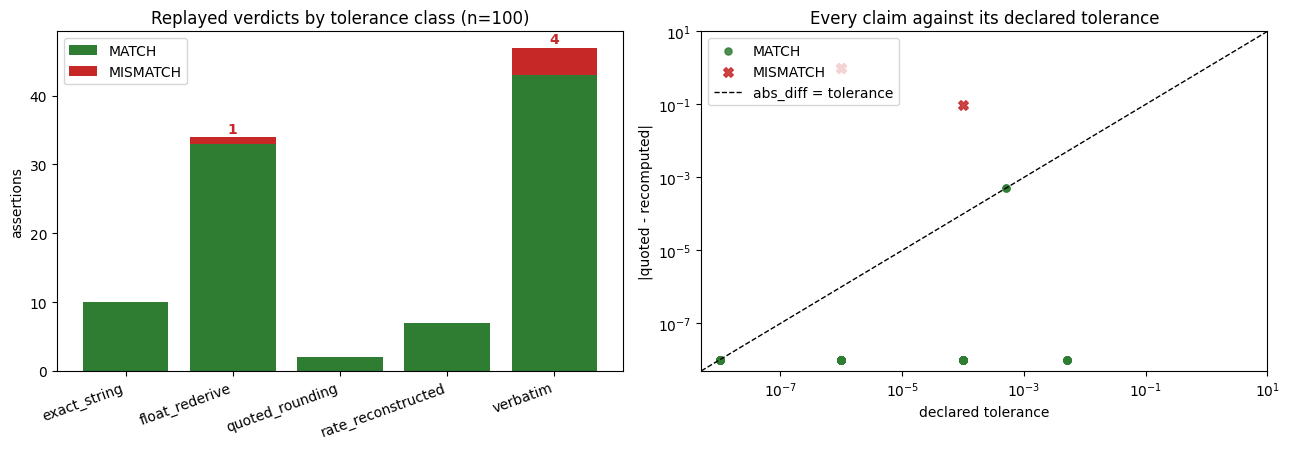


verdicts reproducing the archived run: 100/100
match rate 95/100 = 0.9500  wilson95 [0.8882, 0.9785]


In [11]:
# ---- summary table -------------------------------------------------------
classes = sorted(TOL.keys())
print(f"{'tolerance_class':<22}{'tol':>10}{'n':>6}{'MATCH':>8}{'MISMATCH':>10}")
print("-" * 56)
for c in classes:
    sub = [r for r in replayed if r["tolerance_class"] == c]
    if not sub:
        continue
    m = sum(1 for r in sub if r["verdict"] == "MATCH")
    print(f"{c:<22}{TOL[c]:>10.2e}{len(sub):>6}{m:>8}{len(sub)-m:>10}")
print("-" * 56)
print(f"{'TOTAL':<22}{'':>10}{len(replayed):>6}{counts['MATCH']:>8}{counts['MISMATCH']:>10}")

# ---- figure --------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6))

present = [c for c in classes if any(r["tolerance_class"] == c for r in replayed)]
nmatch = [sum(1 for r in replayed if r["tolerance_class"] == c and r["verdict"] == "MATCH") for c in present]
nmiss = [sum(1 for r in replayed if r["tolerance_class"] == c and r["verdict"] != "MATCH") for c in present]
x = np.arange(len(present))
ax1.bar(x, nmatch, color="#2e7d32", label="MATCH")
ax1.bar(x, nmiss, bottom=nmatch, color="#c62828", label="MISMATCH")
ax1.set_xticks(x); ax1.set_xticklabels(present, rotation=20, ha="right")
ax1.set_ylabel("assertions"); ax1.set_title(f"Replayed verdicts by tolerance class (n={len(replayed)})")
ax1.legend()
for xi, (a, b) in enumerate(zip(nmatch, nmiss)):
    if b: ax1.text(xi, a + b + 0.6, str(b), ha="center", color="#c62828", fontweight="bold")

FLOOR = 1e-8
for verdict, color, mark in (("MATCH", "#2e7d32", "o"), ("MISMATCH", "#c62828", "X")):
    sub = [r for r in replayed if r["verdict"] == verdict]
    if not sub:
        continue
    xs = [max(r["tolerance"], FLOOR) for r in sub]
    ys = [max(r["abs_diff"], FLOOR) if r["abs_diff"] is not None else 1.0 for r in sub]
    ax2.scatter(xs, ys, c=color, marker=mark, s=48 if verdict == "MISMATCH" else 26,
                alpha=0.85, label=verdict, zorder=3 if verdict == "MISMATCH" else 2)
lim = [FLOOR / 2, 10]
ax2.plot(lim, lim, "k--", lw=1, label="abs_diff = tolerance")
ax2.set_xscale("log"); ax2.set_yscale("log"); ax2.set_xlim(*lim); ax2.set_ylim(*lim)
ax2.set_xlabel("declared tolerance"); ax2.set_ylabel("|quoted - recomputed|")
ax2.set_title("Every claim against its declared tolerance")
ax2.legend(loc="upper left")
plt.tight_layout(); plt.show()

print(f"\nverdicts reproducing the archived run: {agree}/{len(replayed)}")
print(f"match rate {k}/{n} = {k/n:.4f}  wilson95 [{wlo:.4f}, {whi:.4f}]")